### Convolutional Neural Networks - CNN
#### Small Image Classifictaion
##### Page 283

In [1]:
import tensorflow as tf 
from tensorflow.keras import datasets, layers, models 
import matplotlib.pyplot as plt 
import numpy as np 

In [2]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Defining callbacks
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

checkpoint_ann = ModelCheckpoint(
    'best_ann_model.keras', 
    save_best_only=True, 
    monitor='val_accuracy'
)

checkpoint_cnn = ModelCheckpoint(
    'best_cnn_model.keras', 
    save_best_only=True, 
    monitor='val_accuracy'
)

In [3]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

c:\Users\xinod\Documents\Projects\CEC616\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000, 1)
(10000, 1)


### These data below are not relevant in this exercise. I have only put them here so that they can be downloaded for future use.

In [4]:
other = datasets.cifar100.load_data()
other2 = datasets.boston_housing.load_data()
other3 = datasets.california_housing.load_data()
other4 = datasets.fashion_mnist.load_data()
other5 = datasets.imdb.load_data()
other6 = datasets.mnist.load_data()
other7 = datasets.reuters.load_data()

print(other, other2, other3, other4, other5, other6, other7)

c:\Users\xinod\Documents\Projects\CEC616\.venv\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


((array([[[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [195, 205, 193],
         [212, 224, 204],
         [182, 194, 167]],

        [[255, 255, 255],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [170, 176, 150],
         [161, 168, 130],
         [146, 154, 113]],

        [[255, 255, 255],
         [254, 254, 254],
         [255, 255, 255],
         ...,
         [189, 199, 169],
         [166, 178, 130],
         [121, 133,  87]],

        ...,

        [[148, 185,  79],
         [142, 182,  57],
         [140, 179,  60],
         ...,
         [ 30,  17,   1],
         [ 65,  62,  15],
         [ 76,  77,  20]],

        [[122, 157,  66],
         [120, 155,  58],
         [126, 160,  71],
         ...,
         [ 22,  16,   3],
         [ 97, 112,  56],
         [141, 161,  87]],

        [[ 87, 122,  41],
         [ 88, 122,  39],
         [101, 134,  56],
         ...,
         [ 34,  36,  10],
      

In [5]:
print(y_train[:5])
y_train = y_train.reshape(-1,)
print(y_train[:5])
y_test = y_test.reshape(-1,)
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

[[6]
 [9]
 [9]
 [4]
 [1]]
[6 9 9 4 1]


In [6]:
def plot_sample(X, y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

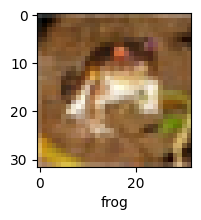

In [7]:
plot_sample(X_train, y_train, 0)

In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

ann = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(2048, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann.fit(
    X_train, y_train, 
    epochs=10, 
    validation_split=0.2, 
    callbacks=[early_stopping, checkpoint_ann]
)

c:\Users\xinod\Documents\Projects\CEC616\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 94s 73ms/step - accuracy: 0.2997 - loss: 1.9309 - val_accuracy: 0.3586 - val_loss: 1.7801
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 68ms/step - accuracy: 0.3852 - loss: 1.7099 - val_accuracy: 0.3968 - val_loss: 1.6992
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 87s 69ms/step - accuracy: 0.4191 - loss: 1.6196 - val_accuracy: 0.4182 - val_loss: 1.6303
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 68ms/step - accuracy: 0.4423 - loss: 1.5575 - val_accuracy: 0.4171 - val_loss: 1.6464
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 141s 67ms/step - accuracy: 0.4568 - loss: 1.5156 - val_accuracy: 0.4329 - val_loss: 1.5844
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 86s 69ms/step - accuracy: 0.4707 - loss: 1.4754 - val_accuracy: 0.4455 - val_loss: 1.5604
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 143s 70ms/step - accuracy: 0.4782 - loss: 1.4463 - val_accuracy: 0.4583 - val_loss: 1.5203
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 140s 68ms/step - accuracy: 0.493

In [9]:
from sklearn.metrics import confusion_matrix, classification_report 
import numpy as np 
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.60      0.52      0.56      1000
           1       0.62      0.55      0.58      1000
           2       0.35      0.31      0.33      1000
           3       0.35      0.27      0.31      1000
           4       0.42      0.42      0.42      1000
           5       0.42      0.34      0.38      1000
           6       0.51      0.54      0.52      1000
           7       0.45      0.63      0.53      1000
           8       0.62      0.59      0.60      1000
           9       0.48      0.67      0.56      1000

    accuracy                           0.48     10000
   macro avg       0.48      0.48      0.48     10000
weighted avg       0.48      0.48      0.48     10000



In [10]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'),
    layers.MaxPool2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

c:\Users\xinod\Documents\Projects\CEC616\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    X_train, y_train, 
    epochs=20, 
    validation_split=0.2, 
    callbacks=[early_stopping, checkpoint_cnn]
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - accuracy: 0.4124 - loss: 1.5854 - val_accuracy: 0.5264 - val_loss: 1.3159
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.5737 - loss: 1.1854 - val_accuracy: 0.6151 - val_loss: 1.1033
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.6431 - loss: 1.0092 - val_accuracy: 0.6285 - val_loss: 1.0402
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.6859 - loss: 0.8914 - val_accuracy: 0.6673 - val_loss: 0.9542
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.7182 - loss: 0.8094 - val_accuracy: 0.6852 - val_loss: 0.9188
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.7421 - loss: 0.7358 - val_accuracy: 0.6799 - val_loss: 0.9525
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.7654 - loss: 0.6706 - val_accuracy: 0.6831 - val_loss: 0.9274
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.7851 -

In [12]:
cnn.evaluate(X_test, y_test)
y_pred = cnn.predict(X_test)
print(y_pred[:5])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6983 - loss: 0.9107
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
[[7.4343108e-05 1.6602568e-04 1.1675757e-02 8.5720646e-01 1.1322924e-03
  9.8455936e-02 3.3338820e-03 5.5357306e-03 2.1866815e-02 5.5269903e-04]
 [6.8517514e-03 8.5167855e-01 8.1632216e-08 4.8898397e-07 1.6273995e-08
  1.0540158e-08 1.3948055e-08 5.5435546e-08 1.4076728e-01 7.0180098e-04]
 [1.8014444e-02 3.5376098e-02 1.0052077e-04 1.3212558e-03 2.6771429e-04
  1.6451882e-04 1.9823550e-04 2.5133247e-04 9.1159171e-01 3.2714132e-02]
 [7.9623944e-01 2.6319277e-02 1.0947712e-03 1.4917043e-03 1.9673917e-02
  8.5280742e-05 6.7494315e-04 4.3714466e-04 1.4981532e-01 4.1682678e-03]
 [1.7843890e-05 5.5487821e-05 3.6262718e-04 1.7491425e-03 2.5001807e-02
  1.7544403e-04 9.7261840e-01 5.6723370e-06 2.0766488e-06 1.1448452e-05]]


In [13]:
y_classes = [np.argmax(element) for element in y_pred]
print(y_classes[:5])

[np.int64(3), np.int64(1), np.int64(8), np.int64(0), np.int64(6)]


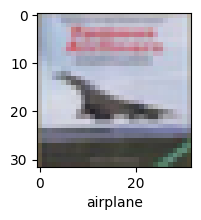

In [14]:
plot_sample(X_test, y_test, 3)

In [15]:
print(classes[y_classes[3]])

airplane
